In [1]:
import numpy as np
import matplotlib.pyplot as pl
from scipy import integrate
import finufft

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
f_max = 100

## Frequency error vs time

In [30]:
def beta_calc(f0, M):
    """M in units of solar masses"""
    Mc = M*2e30
    return const*f0**(8/3)*Mc**(5/3)

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def freq_err(t, f0, M, delta_beta):
    """Error in the frequency from the dephasing
    M in units of solar masses
    """
    beta = beta_calc(f0, M)
    temp0 = (3*f0*delta_beta)/(5*beta*(1-8/3*beta*t)**(3/8))
    temp1 = 1+(-1+beta*t)/(1-8/3*beta*t)
    return temp0*temp1

## Integrating to find lost power

In [31]:
def integrated_func_without_asd(t, f0, M):
    temp0 = np.power((1-8/3*beta_calc(f0, M)*t),-0.5)
    return temp0

def analytical_loss(offset_arr, T, f0, M):
    temp_arr = []
    t_space = np.logspace(0, np.log10(T), 10000)
    for i in offset_arr:
        err_arr = abs(freq_err(t_space, f0, M, i))
        idx = np.argmin(abs(err_arr - 1/(T)))
        crossover_t = t_space[idx]

        temp0 = integrate.quad(integrated_func_without_asd, crossover_t, T, args = (f0, M))[0] 
        temp1 = integrate.quad(integrated_func_without_asd, 0, T, args = (f0, M))[0] 
        temp_arr.append(temp0/temp1)
    return np.array(temp_arr)

In [32]:
f0 = 20
M = 1e-2
beta = beta_calc(f0, M)
obs_duration = 5e3
T = min(obs_duration, t_max_calc(f0, beta, f_max))

offset_arr = np.logspace(-12, -8, 50)

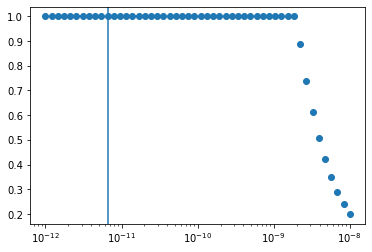

In [33]:
analytical_arr = analytical_loss(-offset_arr, T, f0, M)
pl.semilogx(offset_arr, 1-analytical_arr, 'o')
pl.axvline(offset_arr[10])

## Strobo

In [9]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
    return (resampled, t_out)

In [10]:
f_signal = 20*f_max
nt = round(f_signal*T)
t = np.arange(nt)/f_signal
f_ratio = 25

In [14]:
delta_beta = offset_arr[-2]
phi = -6*pi/5*f0*(1-8./3.*(beta+delta_beta)*t)**(5/8)/(beta+delta_beta)
data = 1*np.exp(1j*phi)
new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta

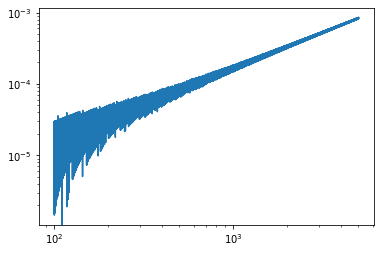

In [26]:
d_phi = np.diff(phi)
d_tau = np.diff(new_t)
idx = t>100
pl.loglog(t[idx][:-1], (d_phi/d_tau/(2*pi)-20)[idx[:-1]])

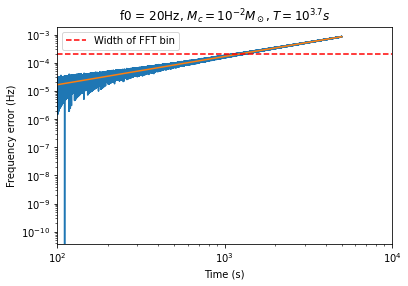

In [29]:
err_arr = abs(freq_err(t, f0, M, delta_beta))
pl.loglog(t[idx][:-1], (d_phi/d_tau/(2*pi)-20)[idx[:-1]])
pl.loglog(t, err_arr/(2*pi))
pl.axhline(1/T, c='r', ls='--', label="Width of FFT bin")
pl.legend()
pl.xlim(1e2, 1e4)
pl.xlabel("Time (s)")
pl.ylabel("Frequency error (Hz)")
pl.title(r"f0 = %.0fHz, $M_c = 10^{%.0f} M_\odot, T = 10^{%.1f}s$" % 
         (f0, np.log10(M), np.log10(T)));

In [19]:
f_ratio = 4
out, t_out = strobo(beta+offset_arr[20], data, f_ratio)
corrected = np.fft.fftshift(np.fft.fft(out))
freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
corrected = corrected[len(corrected)//2:]
resampled_power = np.abs(corrected/len(out))**2

freq_corrected = freq_corrected[len(freq_corrected)//2:]
nt_new = len(out)

(19.9995, 20.0005)

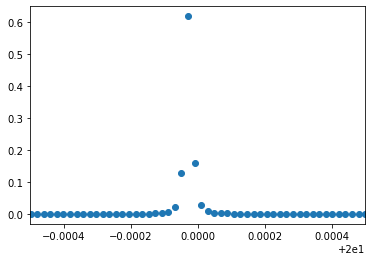

In [20]:
pl.plot(freq_corrected, np.abs(resampled_power), 'o')
pl.xlim(19.9995, 20.0005)